https://www.kaggle.com/datasets/qasimhu/tcgatcga-lihc-viral-status-and-transcriptome

# TCGA-LIHC: Conjunto de dados de hepatite B/C e transcriptômica

**Contagens de RNA-Seq selecionadas e metadados clínicos com rótulos de Hepatite B/C extraídos.**

# Contexto

O carcinoma hepatocelular (CHC) é o tipo mais comum de câncer primário de fígado e está frequentemente associado a infecções virais. Embora o Atlas do Genoma do Câncer (TCGA) forneça dados genômicos abrangentes, o status viral específico (hepatite B versus hepatite C) dos pacientes muitas vezes fica oculto em metadados clínicos não estruturados, dificultando a análise das etiologias virais por cientistas de dados.

Este conjunto de dados fornece uma análise detalhada da etiologia viral , otimizada para aprendizado de máquina, juntamente com contagens brutas de expressão gênica.

# 1. Dados Clínicos ( TCGA_LIHC_Clinical_Viral_Final.csv)

ID do Paciente: O código de barras TCGA.
Status_do_vírus: O rótulo do alvo. Categorias: HBV(Hepatite B), HCV(Hepatite C), Co-Infection, ou Non-Viral.
Estado_Vital: Dead ou Alive.
Dias até o óbito: para análise de sobrevivência (variável alvo).
Metodologia: O estado viral foi extraído da viral_hepatitis_serologiescoluna XML bruta usando correspondência de padrões regex (buscando texto específico de antígeno/anticorpo) para classificar os pacientes com precisão.

# 2. Dados Genômicos ( TCGA_LIHC_Gene_Expression.csv)

Linhas: IDs de genes Ensembl (ex.: ENSG00000000003).
Colunas: Códigos de barras do paciente (correspondem ao arquivo clínico).
Valores: Contagens brutas de leitura de RNA-Seq (HTSeq - Contagens). Adequado para análise de expressão diferencial (DESeq2/edgeR).
Agradecimentos e fonte
Esses dados foram obtidos do Portal de Dados GDC do Instituto Nacional do Câncer usando o TCGAbiolinkspacote R.

# Fonte original: Rede de Pesquisa do Atlas do Genoma do Câncer (TCGA): https://www.cancer.gov/tcga

# Licença: Os dados são de Acesso Aberto. Os usuários devem citar a fonte original (TCGA) em todas as publicações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_viral = pd.read_csv('TCGA_LIHC_Clinical_Viral.csv')
df_gene = pd.read_csv('TCGA_LIHC_Gene_Expression.csv', index_col=0)

# EAD

In [2]:
#Dimensões
print(f"Clínico: {df_viral.shape}")
print(f"Expressão: {df_gene.shape}")

df_viral.head()

Clínico: (377, 9)
Expressão: (60660, 424)


,Patient_ID,days_to_death,days_to_last_followup,gender,viral_hepatitis_serologies,history_hepato_carcinoma_risk_factors,Is_HBV,Is_HCV,Virus_Status
0,TCGA-2V-A95S,NaN,NaN,MALE,NaN,Otherformer smoker,False,False,Non-Viral/Unknown
1,TCGA-2Y-A9GS,724.0,NaN,MALE,HCV GenotypeHepatitis B Surface AntigenHBV Cor...,Alcohol consumption,True,True,Co-Infection
2,TCGA-2Y-A9GT,1624.0,NaN,MALE,Hepatitis C Virus RNAHepatitis B Surface Antig...,Alcohol consumptionHepatitis BHepatitis C,True,True,Co-Infection
3,TCGA-2Y-A9GU,NaN,1939.0,FEMALE,Hepatitis C AntibodyHepatitis B Surface Antig...,No History of Primary Risk Factors,True,False,HBV
4,TCGA-2Y-A9GV,2532.0,NaN,FEMALE,Hepatitis C AntibodyHepatitis B Surface Antig...,Alcohol consumption,True,False,HBV


In [3]:
#Limpeza
#Transpor para ter genes como colunas e amostras como linhas
df_gene_t = df_gene.T

#Ajustar IDs: 'TCGA-XX-XXXX-01A...' -> 'TCGA-XX-XXXX'
df_gene_t.index = df_gene_t.index.str.slice(0, 12)

#Unir os datasets com base no ID do paciente
df_merged = pd.merge(df_viral, df_gene_t, left_on='Patient_ID', right_index=True)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4300\1079664204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merged, x='Virus_Status', palette='flare')


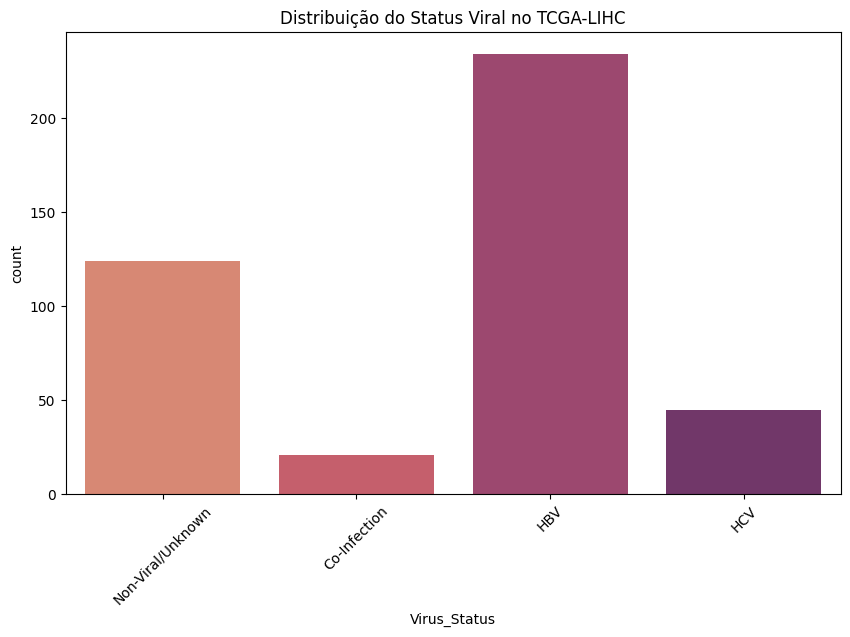

In [4]:
#Análise da Variável Alvo (Virus_Status)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_merged, x='Virus_Status', palette='flare')
plt.title('Distribuição do Status Viral no TCGA-LIHC')
plt.xticks(rotation=45)
plt.show()

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


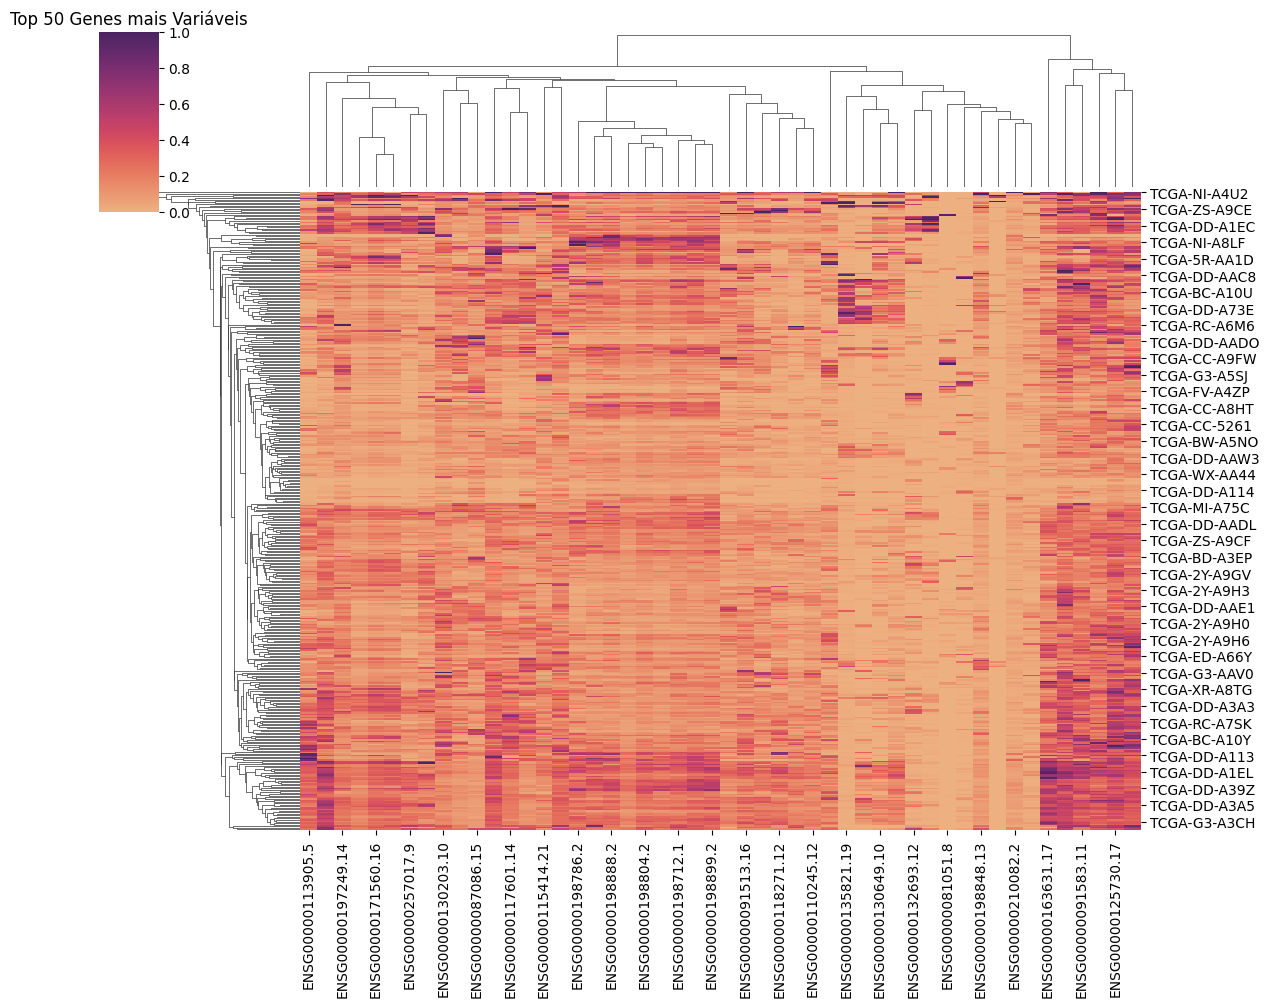

In [5]:
#Visualização de Expressão Gênica (Heatmap)
#Calcular a variância e pegar os 50 genes mais variáveis
top_genes = df_gene_t.var().sort_values(ascending=False).head(50).index
df_subset = df_gene_t[top_genes]

# Plotar Heatmap escalonado (Z-score)
sns.clustermap(df_subset, cmap='flare', standard_scale=1, figsize=(12, 10))
plt.title('Top 50 Genes mais Variáveis')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4300\2424500223.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='Virus_Status', y='time', palette='viridis')


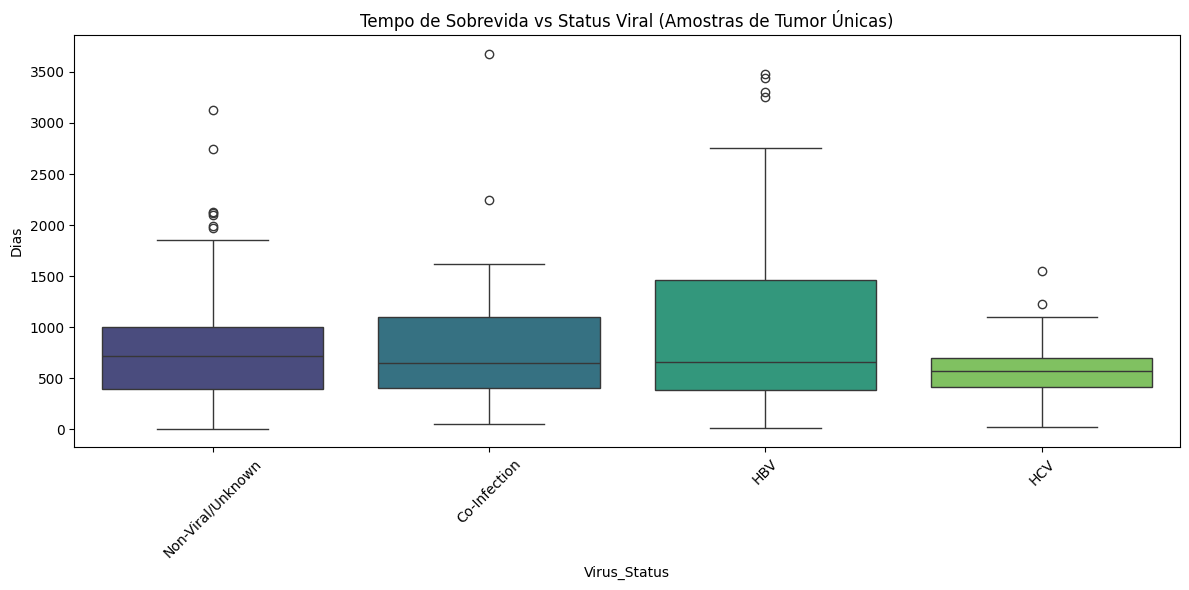

In [6]:
#Análise de Sobrevivência
#Filtrar apenas amostras de Tumor Primário (Código '01' na posição 13-15)
#O ID TCGA-XX-XXXX-01A... indica tumor, enquanto TCGA-XX-XXXX-11A... indica normal.
tumor_columns = [col for col in df_gene.columns if col.split('-')[3].startswith('01')]
df_gene_tumor = df_gene[tumor_columns].T

#Ajustar o índice para 12 caracteres e remover duplicatas remanescentes (se houver)
df_gene_tumor.index = df_gene_tumor.index.str.slice(0, 12)
df_gene_tumor = df_gene_tumor[~df_gene_tumor.index.duplicated(keep='first')]

#Mesclar com os dados clínicos
df_merged = pd.merge(df_viral, df_gene_tumor, left_on='Patient_ID', right_index=True)

#Converter colunas de tempo para numérico (evita erros de plotagem)
df_merged['days_to_death'] = pd.to_numeric(df_merged['days_to_death'], errors='coerce')
df_merged['days_to_last_followup'] = pd.to_numeric(df_merged['days_to_last_followup'], errors='coerce')

#Criar a coluna unificada de tempo (sobrevida ou último acompanhamento)
df_merged['time'] = df_merged['days_to_death'].fillna(df_merged['days_to_last_followup'])

#Boxplot 
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_merged, x='Virus_Status', y='time', palette='viridis')
plt.title('Tempo de Sobrevida vs Status Viral (Amostras de Tumor Únicas)')
plt.xticks(rotation=45)
plt.ylabel('Dias')
plt.tight_layout()
plt.show()

# Execução dos Testes Estatísticos

In [7]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

#Filtrar grupos
grupo_hbv = df_merged[df_merged['Virus_Status'] == 'HBV']
grupo_hcv = df_merged[df_merged['Virus_Status'] == 'HCV']

#Lista de genes para testar (excluindo as colunas clínicas)
#Assumindo que os genes começam após as colunas clínicas que adicionamos
genes = df_gene_tumor.columns

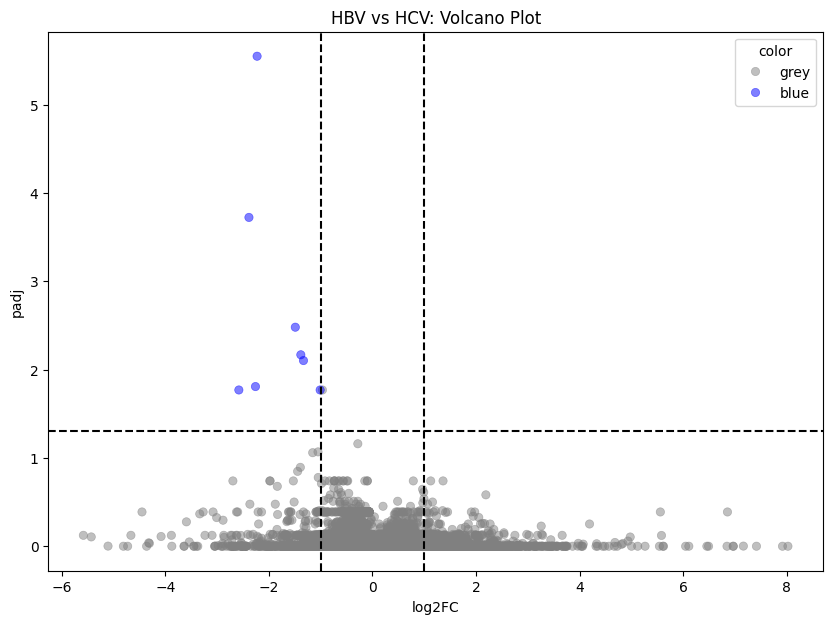

In [8]:
results = []

for gene in genes:
    exp_hbv = grupo_hbv[gene]
    exp_hcv = grupo_hcv[gene]
    
    #Teste de Wilcoxon
    stat, pval = mannwhitneyu(exp_hbv, exp_hcv, alternative='two-sided')
    
    #Calcular Log2 Fold Change: log2(média_HBV / média_HCV)
    #Adicionar +1 (pseudocount) para evitar divisão por zero ou log de zero
    lfc = np.log2((exp_hbv.mean() + 1) / (exp_hcv.mean() + 1))
    
    results.append({'Gene': gene, 'p_value': pval, 'log2FC': lfc})

df_dea = pd.DataFrame(results)

#Correção de p-valor para múltiplos testes (FDR/Benjamini-Hochberg)
df_dea['padj'] = multipletests(df_dea['p_value'], method='fdr_bh')[1]

plt.figure(figsize=(10, 7))

#Definir limites de significância
alpha = 0.05
lfc_threshold = 1.0

#Colorir genes significativos
df_dea['color'] = 'grey'
df_dea.loc[(df_dea['padj'] < alpha) & (df_dea['log2FC'] > lfc_threshold), 'color'] = 'red' # Up no HBV
df_dea.loc[(df_dea['padj'] < alpha) & (df_dea['log2FC'] < -lfc_threshold), 'color'] = 'blue' # Up no HCV

sns.scatterplot(data=df_dea, x='log2FC', y=-np.log10(df_dea['padj']), 
                hue='color', palette={'grey': 'grey', 'red': 'red', 'blue': 'blue'},
                alpha=0.5, edgecolor=None)

plt.axhline(-np.log10(alpha), color='black', linestyle='--')
plt.axvline(lfc_threshold, color='black', linestyle='--')
plt.axvline(-lfc_threshold, color='black', linestyle='--')
plt.title('HBV vs HCV: Volcano Plot')
plt.show()

In [9]:
#Top 10 genes mais diferencialmente expressos (p-ajustado menor)
top_genes = df_dea.sort_values('padj').head(10)
print(top_genes)

                     Gene       p_value    log2FC      padj color
11720  ENSG00000165949.12  4.664905e-11 -2.228011  0.000003  blue
35651   ENSG00000240671.4  6.239265e-09 -2.385335  0.000189  blue
46761   ENSG00000261613.2  1.637895e-07 -1.490051  0.003312  blue
7575   ENSG00000137965.11  4.481502e-07 -1.383526  0.006796  blue
7699    ENSG00000138646.9  6.511270e-07 -1.332616  0.007899  blue
16488  ENSG00000187608.10  1.539182e-06 -2.259387  0.015561  blue
6714   ENSG00000133106.15  2.436715e-06 -1.010773  0.017014  blue
6242   ENSG00000130303.13  2.263051e-06 -0.966223  0.017014  grey
56537   ENSG00000281990.1  2.524387e-06 -2.580221  0.017014  blue
15924   ENSG00000185221.6  1.139771e-05 -0.283109  0.069139  grey


In [10]:
import gseapy as gp
#Limpeza dos nomes dos genes (Remover versões de IDs Ensembl, se houver)
df_dea['Gene_Clean'] = df_dea['Gene'].str.split('.').str[0]

#Filtrar genes significativos
criterio = (df_dea['padj'] < 0.05) & (df_dea['log2FC'].abs() > 1.0)
genes_significativos = df_dea[criterio]['Gene_Clean'].unique().tolist()

print(f"Total de genes para enriquecimento: {len(genes_significativos)}")

if len(genes_significativos) > 0:
    
    enr = gp.enrichr(gene_list=genes_significativos,
                     gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human'],
                     organism='human', 
                     outdir=None)

    #Visualização dos 10 termos mais relevantes
    res = enr.results
    top_terms = res[res['Adjusted P-value'] < 0.05].sort_values('Combined Score', ascending=False).head(10)

    if not top_terms.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=top_terms, x='Combined Score', y='Term', palette='viridis')
        plt.title('Top 10 Vias Biológicas Enriquecidas (HBV vs HCV)')
        plt.xlabel('Combined Score')
        plt.ylabel('Processo Biológico / Via')
        plt.tight_layout()
        plt.show()
    else:
        print("Nenhum termo estatisticamente significativo foi encontrado no enriquecimento.")
else:
    print("A lista de genes significativos está vazia. Verifique os critérios do teste de Wilcoxon.")

Total de genes para enriquecimento: 8
Nenhum termo estatisticamente significativo foi encontrado no enriquecimento.


In [11]:
#Relaxando os critérios para tentar capturar um sinal biológico
criterio_relaxado = (df_dea['p_value'] < 0.05) & (df_dea['log2FC'].abs() > 0.5)
genes_relaxados = df_dea[criterio_relaxado]['Gene_Clean'].unique().tolist()

print(f"Novo total de genes: {len(genes_relaxados)}")

Novo total de genes: 1063


# ML

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#Filtrar apenas pacientes HBV e HCV (remover co-infecções e desconhecidos para o modelo)
df_ml = df_merged[df_merged['Virus_Status'].isin(['HBV', 'HCV'])].copy()

#Definir Alvo (Y) e Características (X)
top_100_genes = df_dea.sort_values('p_value').head(100)['Gene'].tolist()

X = df_ml[top_100_genes]
y = df_ml['Virus_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Inicializar e treinar
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Predições
y_pred = rf.predict(X_test)

#Resultados
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Matriz de Confusão:
[[42  1]
 [ 4  4]]

Relatório de Classificação:
              precision    recall  f1-score   support

         HBV       0.91      0.98      0.94        43
         HCV       0.80      0.50      0.62         8

    accuracy                           0.90        51
   macro avg       0.86      0.74      0.78        51
weighted avg       0.90      0.90      0.89        51



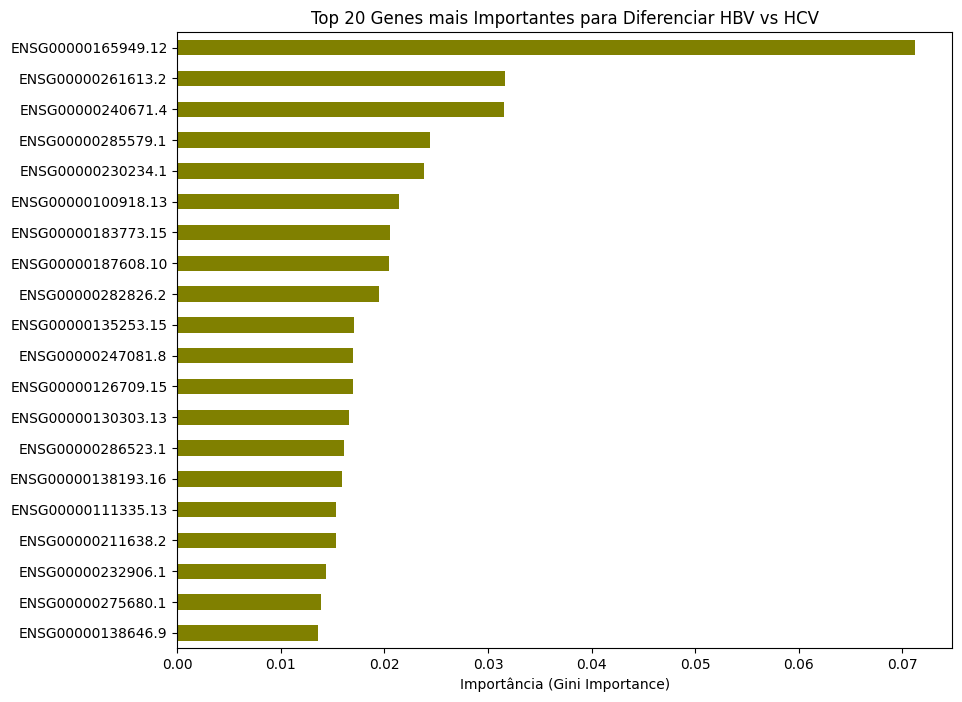

In [13]:
#Importância das características
importances = pd.Series(rf.feature_importances_, index=top_100_genes).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh', color='olive')
plt.title('Top 20 Genes mais Importantes para Diferenciar HBV vs HCV')
plt.xlabel('Importância (Gini Importance)')
plt.gca().invert_yaxis()
plt.show()

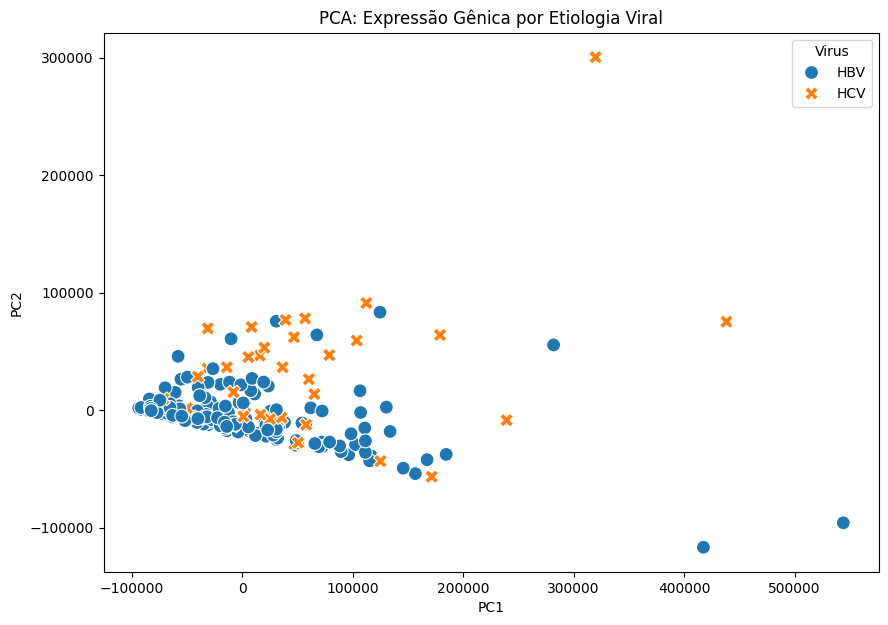

In [14]:
from sklearn.decomposition import PCA

# X_ml contém a expressão gênica, y_ml contém o status viral
pca = PCA(n_components=2)
components = pca.fit_transform(X) # X deve estar escalonado (StandardScaler)

df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['Virus'] = y.values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Virus', style='Virus', s=100)
plt.title('PCA: Expressão Gênica por Etiologia Viral')
plt.show()

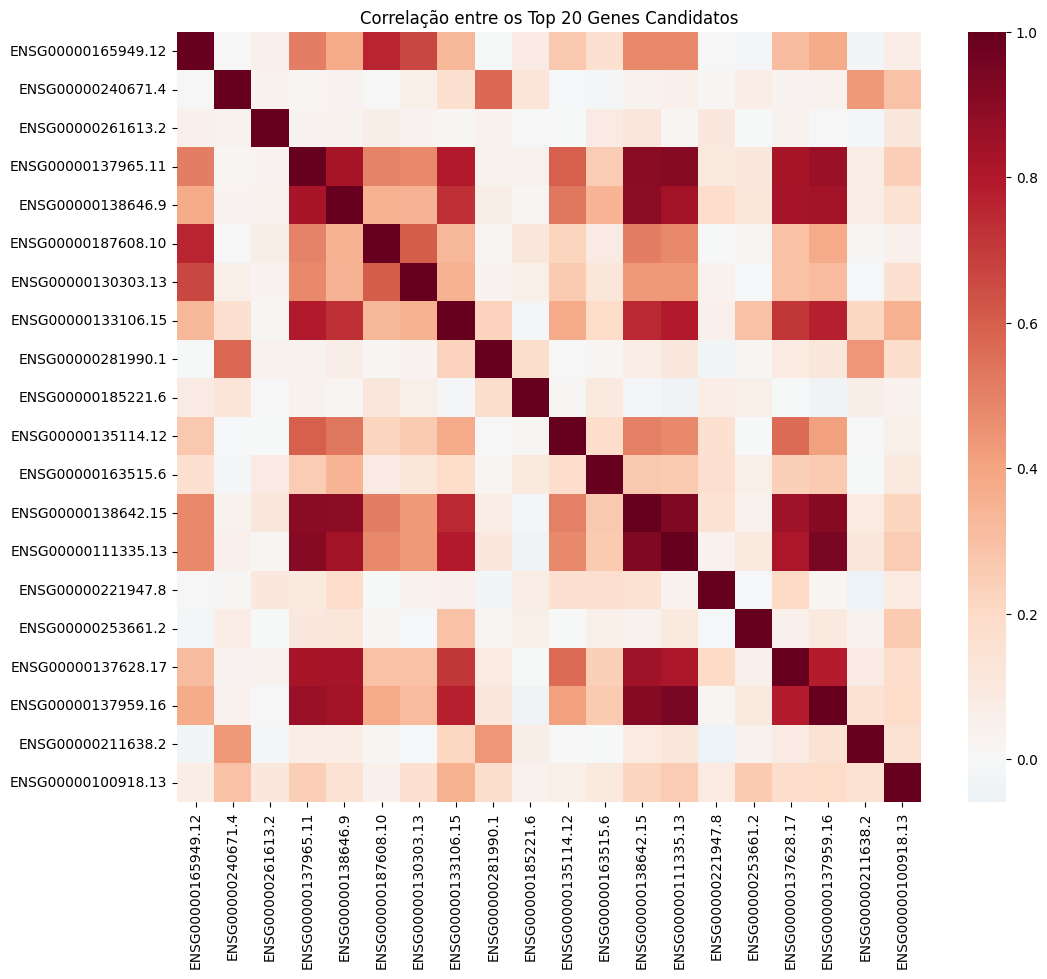

In [15]:
#Top 20 genes do teste estatístico
top_genes = df_dea.sort_values('p_value').head(20)['Gene']
corr_matrix = X[top_genes].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Correlação entre os Top 20 Genes Candidatos')
plt.show()

In [16]:
#Verificação de Desbalanceamento (Otimização de ML)
print("Distribuição de classes para o modelo:")
print(y.value_counts(normalize=True) * 100)

Distribuição de classes para o modelo:
Virus_Status
HBV    83.333333
HCV    16.666667
Name: proportion, dtype: float64


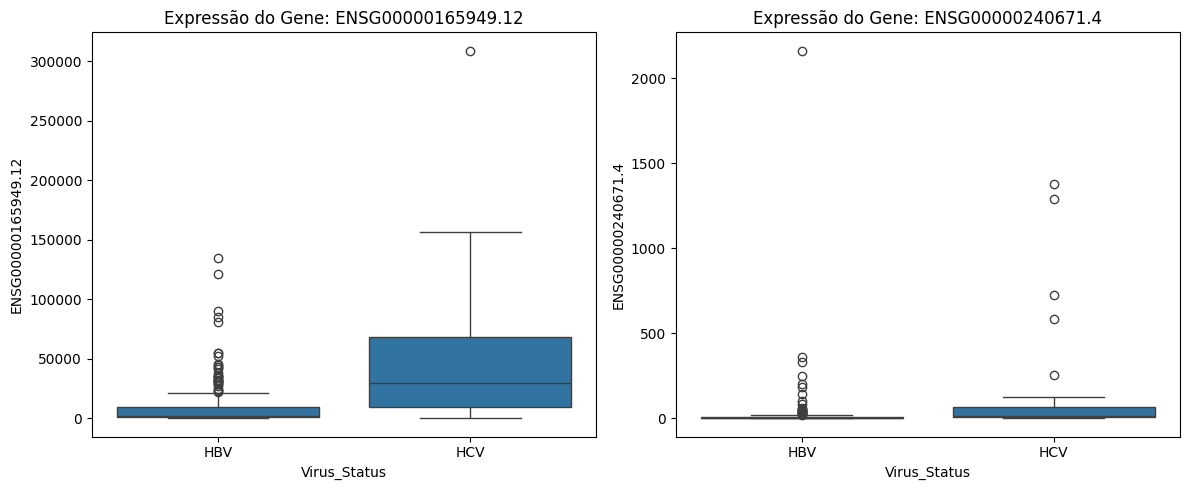

In [17]:
#Garantindo que a proporção 83/17 se mantenha no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  
)

from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(class_weight='balanced')

#Boxplot comparativo dos 2 genes com menor p-valor
top_2_genes = df_dea.sort_values('p_value').head(2).Gene.tolist()

plt.figure(figsize=(12, 5))
for i, gene in enumerate(top_2_genes, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=df_ml, x='Virus_Status', y=gene)
    plt.title(f'Expressão do Gene: {gene}')
plt.tight_layout()
plt.show()

Relatório de Classificação (Ajustado por Pesos):
              precision    recall  f1-score   support

         HBV       0.96      1.00      0.98        43
         HCV       1.00      0.75      0.86         8

    accuracy                           0.96        51
   macro avg       0.98      0.88      0.92        51
weighted avg       0.96      0.96      0.96        51



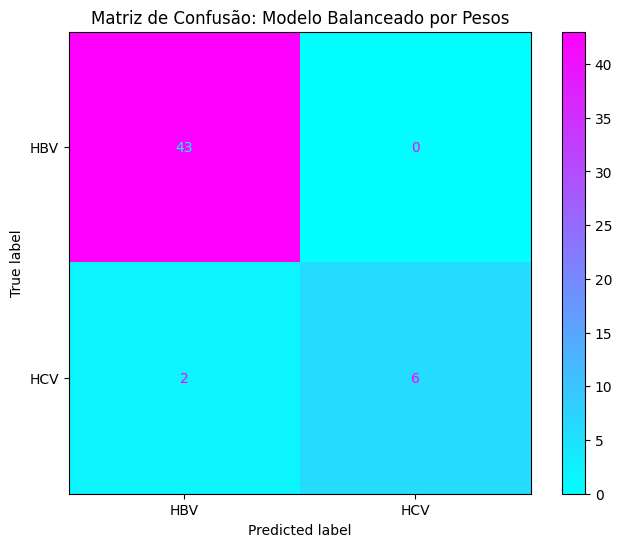

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Preparar os dados (usando os top 100 genes da DEA)
top_features = df_dea.sort_values('p_value').head(100)['Gene'].tolist()
X = df_ml[top_features]
y = df_ml['Virus_Status']

#Divisão Estratificada (Mantém a proporção de 17% de HCV)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Pipeline Nativo (Sem SMOTE para evitar erros de compatibilidade)
#Parâmetro class_weight='balanced' faz o trabalho de compensar o desbalanceamento
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced', # <--- A mágica acontece aqui
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Relatório de Classificação (Ajustado por Pesos):")
print(classification_report(y_test, y_pred))

#Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='cool', ax=ax)
plt.title('Matriz de Confusão: Modelo Balanceado por Pesos')
plt.show()

# Extração de Biomarcadores

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4300\3598264269.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(15), x='Importancia', y='Gene_ID', palette='rocket')


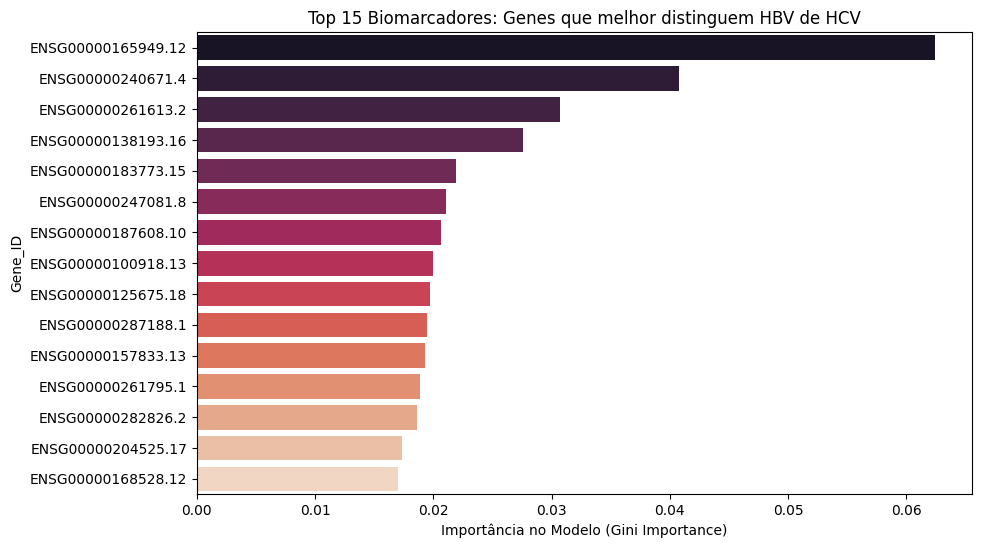

In [19]:
#Importância das características dentro do pipeline
importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = top_features # Nossos 100 genes Ensembl

#Criar um DataFrame de Importância
df_importancia = pd.DataFrame({
    'Gene_ID': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

#Top 15
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia.head(15), x='Importancia', y='Gene_ID', palette='rocket')
plt.title('Top 15 Biomarcadores: Genes que melhor distinguem HBV de HCV')
plt.xlabel('Importância no Modelo (Gini Importance)')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4300\163253464.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(15), x='Importance', y='Ensembl_ID', palette='viridis')


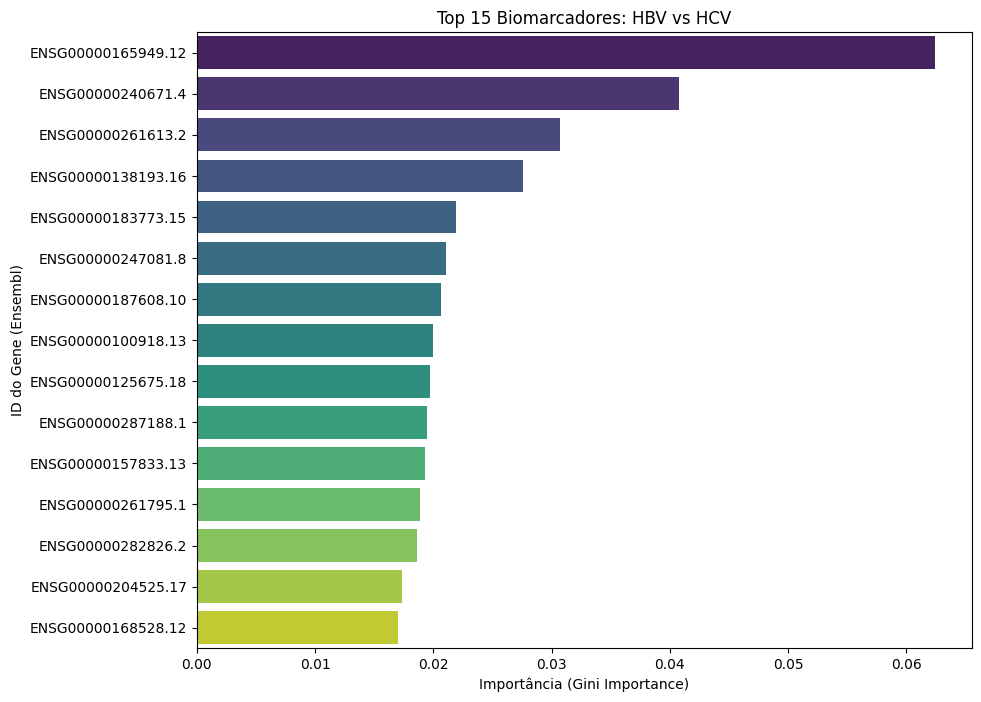

In [20]:
#Importância das características dentro do pipeline
importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = top_features  # Os 100 genes que enviamos ao modelo

df_importancia = pd.DataFrame({
    'Ensembl_ID': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#Visualizar os 15 genes mais influentes
plt.figure(figsize=(10, 8))
sns.barplot(data=df_importancia.head(15), x='Importance', y='Ensembl_ID', palette='viridis')
plt.title('Top 15 Biomarcadores: HBV vs HCV')
plt.xlabel('Importância (Gini Importance)')
plt.ylabel('ID do Gene (Ensembl)')
plt.show()

# Análise de Sobrevida: HBV vs. HCV

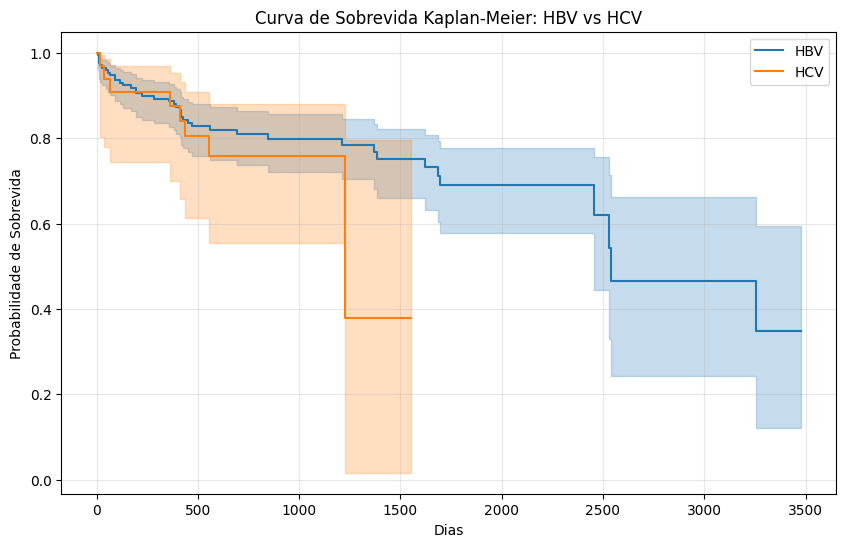

In [21]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

#Filtrar grupos
df_surv = df_merged[df_merged['Virus_Status'].isin(['HBV', 'HCV'])].copy()
df_surv['event'] = df_surv['days_to_death'].notna().astype(int)
df_surv['time'] = df_surv['days_to_death'].fillna(df_surv['days_to_last_followup'])
df_surv = df_surv.dropna(subset=['time'])

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
for status in ['HBV', 'HCV']:
    mask = (df_surv['Virus_Status'] == status)
    kmf.fit(df_surv['time'][mask], df_surv['event'][mask], label=status)
    kmf.plot_survival_function()

plt.title('Curva de Sobrevida Kaplan-Meier: HBV vs HCV')
plt.xlabel('Dias')
plt.ylabel('Probabilidade de Sobrevida')
plt.grid(alpha=0.3)
plt.show()

O HBV está associado a uma integração viral no DNA do hospedeiro que pode levar a um fenótipo mais agressivo, enquanto o HCV está mais ligado à inflamação crônica e cirrose. A curva mostrará se essa diferença biológica se traduz em tempo de vida.

# Expressão Diferencial: Viral vs. Álcool (Não Viral)

Comparando 252 amostras Virais vs 38 amostras de Álcool...


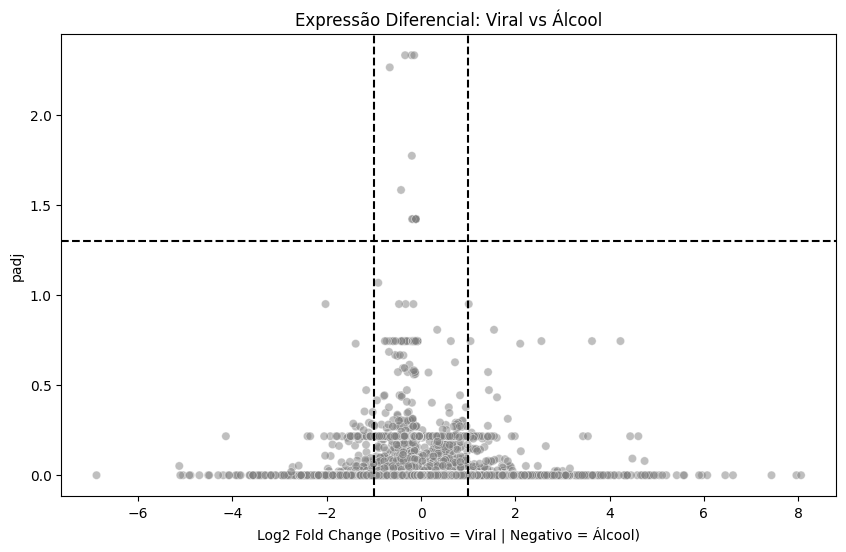


Top 10 Genes com expressão aumentada no grupo Viral:
                     Gene   p_value    log2FC      padj
37535   ENSG00000247627.2  0.000035  1.012943  0.112334
56061   ENSG00000280145.3  0.000054  1.548484  0.156091
659    ENSG00000049247.14  0.000273  2.553837  0.180284
10452  ENSG00000160223.17  0.000171  1.050024  0.180284
12052  ENSG00000167244.21  0.000266  4.230142  0.180284
2128    ENSG00000099869.8  0.000120  3.626490  0.180284
24866   ENSG00000223722.3  0.000289  2.104016  0.186391
15286  ENSG00000182612.10  0.000473  1.422560  0.267770
4782   ENSG00000118194.20  0.000657  1.441137  0.337178
44759   ENSG00000258976.1  0.000768  1.612116  0.369798


In [22]:
#Definição dos Grupos (conforme sua lógica)
df_merged['Group'] = 'Outros'
df_merged.loc[df_merged['Virus_Status'].isin(['HBV', 'HCV']), 'Group'] = 'Viral'
df_merged.loc[(df_merged['Virus_Status'] == 'Non-Viral/Unknown') & 
              (df_merged['history_hepato_carcinoma_risk_factors'].str.contains('Alcohol', na=False)), 'Group'] = 'Alcohol'

#Filtrar apenas os dois grupos para comparação
df_contrast = df_merged[df_merged['Group'].isin(['Viral', 'Alcohol'])]

#Teste de Wilcoxon
genes = [col for col in df_gene_tumor.columns] # Assumindo que df_gene_tumor contém os genes
results_v_a = []

grupo_v = df_contrast[df_contrast['Group'] == 'Viral']
grupo_a = df_contrast[df_contrast['Group'] == 'Alcohol']

print(f"Comparando {len(grupo_v)} amostras Virais vs {len(grupo_a)} amostras de Álcool...")

for gene in genes:
    exp_v = grupo_v[gene]
    exp_a = grupo_a[gene]
    
    #Teste estatístico
    stat, pval = mannwhitneyu(exp_v, exp_a, alternative='two-sided')
    
    #Log2 Fold Change (Viral / Alcohol)
    lfc = np.log2((exp_v.mean() + 1) / (exp_a.mean() + 1))
    
    results_v_a.append({'Gene': gene, 'p_value': pval, 'log2FC': lfc})

#Processamento de Resultados
df_dea_va = pd.DataFrame(results_v_a)
df_dea_va['padj'] = multipletests(df_dea_va['p_value'], method='fdr_bh')[1]

#Visualização: Volcano Plot
plt.figure(figsize=(10, 6))
#Genes que sobem no Viral (Vermelho) e que sobem no Álcool (Azul)
sns.scatterplot(data=df_dea_va, x='log2FC', y=-np.log10(df_dea_va['padj']), 
                hue=(df_dea_va['padj'] < 0.05) & (df_dea_va['log2FC'].abs() > 1),
                palette={True: 'red', False: 'grey'}, alpha=0.5, legend=False)

plt.axhline(-np.log10(0.05), color='black', linestyle='--')
plt.axvline(1, color='black', linestyle='--')
plt.axvline(-1, color='black', linestyle='--')
plt.title('Expressão Diferencial: Viral vs Álcool')
plt.xlabel('Log2 Fold Change (Positivo = Viral | Negativo = Álcool)')
plt.show()

#Top Genes aumentados no Viral
top_viral = df_dea_va[df_dea_va['log2FC'] > 1].sort_values('padj').head(10)
print("\nTop 10 Genes com expressão aumentada no grupo Viral:")
print(top_viral)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4300\3365170040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_contrast['event'] = df_contrast['days_to_death'].notna().astype(int)
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4300\3365170040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_contrast['time'] = df_contrast['days_to_death'].fillna(df_contrast['days_to_last_followup'])


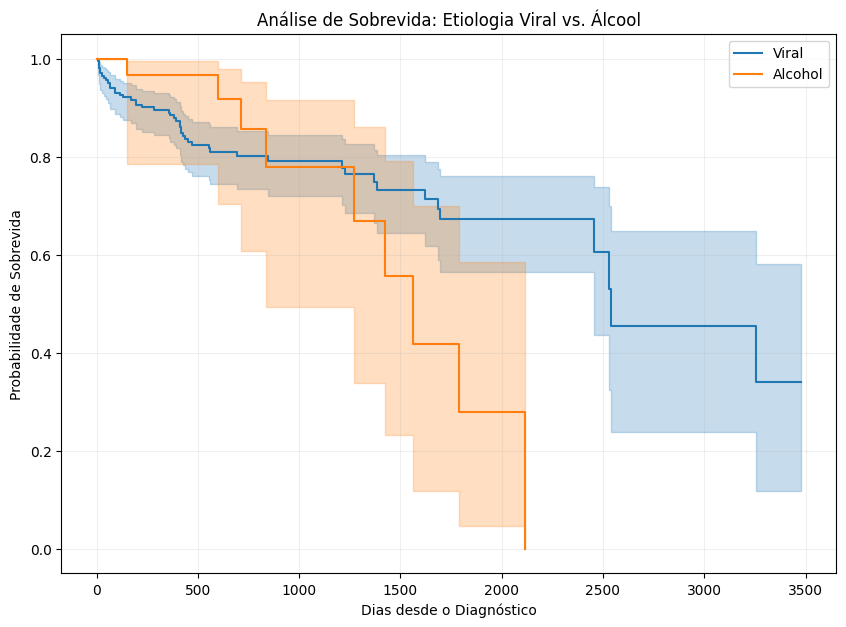

In [23]:
df_contrast['event'] = df_contrast['days_to_death'].notna().astype(int)
df_contrast['time'] = df_contrast['days_to_death'].fillna(df_contrast['days_to_last_followup'])

#Remover pacientes sem informação de tempo
df_surv_final = df_contrast.dropna(subset=['time'])

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 7))

#Plotar para cada grupo
for label in ['Viral', 'Alcohol']:
    mask = (df_surv_final['Group'] == label)
    kmf.fit(df_surv_final['time'][mask], df_surv_final['event'][mask], label=label)
    kmf.plot_survival_function(ci_show=True) # ci_show mostra o intervalo de confiança

plt.title('Análise de Sobrevida: Etiologia Viral vs. Álcool')
plt.xlabel('Dias desde o Diagnóstico')
plt.ylabel('Probabilidade de Sobrevida')
plt.grid(alpha=0.2)
plt.show()

In [ ]:
#Top 10 genes baseados no p-valor ajustado
#Filtrando para mostrar o que sobe no Viral e o que sobe no Álcool
top_viral_markers = df_dea_va[df_dea_va['log2FC'] > 1.5].sort_values('padj').head(10)
top_alcohol_markers = df_dea_va[df_dea_va['log2FC'] < -1.5].sort_values('padj').head(10)

#Concatenar para uma tabela mestre
tabela_final = pd.concat([top_viral_markers, top_alcohol_markers])
tabela_final['Assinatura'] = tabela_final['log2FC'].apply(lambda x: 'Viral' if x > 0 else 'Álcool')

#Exibir a tabela formatada
print(tabela_final[['Gene', 'log2FC', 'padj', 'Assinatura']].to_string(index=False))
tabela_final.to_csv('tabela_biomarcadores_etiologia.csv', index=False)

              Gene    log2FC     padj Assinatura
 ENSG00000280145.3  1.548484 0.156091      Viral
ENSG00000049247.14  2.553837 0.180284      Viral
 ENSG00000099869.8  3.626490 0.180284      Viral
ENSG00000167244.21  4.230142 0.180284      Viral
 ENSG00000223722.3  2.104016 0.186391      Viral
 ENSG00000258976.1  1.612116 0.369798      Viral
ENSG00000035115.22  1.840875 0.486606      Viral
 ENSG00000231107.2  1.551160 0.607695      Viral
ENSG00000198300.14  3.435289 0.607695      Viral
ENSG00000126259.20  4.436406 0.607695      Viral
ENSG00000165623.10 -2.024808 0.112334     Álcool
ENSG00000106536.21 -1.530678 0.607695     Álcool
ENSG00000182048.11 -2.053672 0.607695     Álcool
 ENSG00000274749.1 -1.780267 0.607695     Álcool
 ENSG00000168903.9 -1.672030 0.607695     Álcool
ENSG00000169064.13 -1.803863 0.607695     Álcool
ENSG00000122852.15 -1.924244 0.607695     Álcool
 ENSG00000229550.1 -2.350841 0.607695     Álcool
 ENSG00000283659.1 -4.138676 0.607695     Álcool
ENSG00000030304.14 -

| Característica                                    | Câncer Induzido por Vírus (HBV/HCV)                                                                                                        | Câncer Induzido por Álcool                                                                                                               |
| ------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **Perfil Genético**                               | Ativação de vias inflamatórias e de interferon (assinatura imune bem definida).                                                            | Alterações no metabolismo redox e na degradação de lipídios.                                                                             |
| **Sobrevida**                                     | Tende a apresentar quedas mais bruscas quando a carga viral é alta ou há integração genômica viral.                                        | Frequentemente associada a quadros graves de cirrose, comprometendo a função hepática global.                                            |
| **Predição (ML)**                                 | Altamente identificável (assinatura molecular muito “barulhenta” e específica).                                                            | Perfil mais heterogêneo, dependente do tempo de exposição e da extensão dos danos metabólicos.                                           |
| **Implicações Clínicas / Resposta ao Tratamento** | Potencial benefício de estratégias combinadas: antivirais + imunoterapia; resposta mais previsível quando a replicação viral é controlada. | Resposta terapêutica mais limitada e variável; manejo fortemente dependente da reversibilidade da cirrose e da função hepática residual. |

In [25]:
from lifelines.statistics import logrank_test

#Preparar os dados para o teste
#Grupo Viral
mask_v = (df_surv_final['Group'] == 'Viral')
T_v = df_surv_final['time'][mask_v]
E_v = df_surv_final['event'][mask_v]

#Grupo Álcool
mask_a = (df_surv_final['Group'] == 'Alcohol')
T_a = df_surv_final['time'][mask_a]
E_a = df_surv_final['event'][mask_a]

#Executar o Log-Rank Test
results = logrank_test(T_v, T_a, event_observed_A=E_v, event_observed_B=E_a)

print(f"--- Estatística de Sobrevida (Viral vs Álcool) ---")
print(f"P-valor: {results.p_value:.4f}")
print(f"Estatística de Teste: {results.test_statistic:.4f}")

if results.p_value < 0.05:
    print("\nConclusão: Existe uma diferença significativa na sobrevida entre as etiologias.")
else:
    print("\nConclusão: Não há evidência estatística de que a etiologia altera o tempo de sobrevida.")

--- Estatística de Sobrevida (Viral vs Álcool) ---
P-valor: 0.3805
Estatística de Teste: 0.7690

Conclusão: Não há evidência estatística de que a etiologia altera o tempo de sobrevida.


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("<b>A.</b> Matriz de Confusão", "<b>B.</b> Importância dos Genes", 
                    "<b>C.</b> Volcano Plot (Viral vs Álcool)", "<b>D.</b> Curva de Sobrevida"),
    vertical_spacing=0.12,
    horizontal_spacing=0.1,
    specs=[[{"type": "heatmap"}, {"type": "bar"}],
           [{"type": "scatter"}, {"type": "scatter"}]]
)

# --- Subplot A: Matriz de Confusão ---
fig.add_trace(
    go.Heatmap(
        z=[[43, 0], [2, 6]], 
        x=['HBV', 'HCV (Predito)'], 
        y=['HBV', 'HCV (Real)'], 
        colorscale='Blues', 
        showscale=False,
        text=[[43, 0], [2, 6]], texttemplate="%{text}", textfont={"size":16}
    ),
    row=1, col=1
)

# --- Subplot B: Importância dos Genes ---
# Invertendo a ordem para o maior ficar no topo da barra horizontal
fig.add_trace(
    go.Bar(
        x=df_importancia.head(10)['Importance'][::-1], 
        y=df_importancia.head(10)['Ensembl_ID'][::-1], 
        orientation='h', 
        marker=dict(color='#2c3e50'),
        name='Importância Gini'
    ),
    row=1, col=2
)

# --- Subplot C: Volcano Plot ---
# Pontos Não Significativos
fig.add_trace(
    go.Scatter(
        x=df_dea_va[~sig_mask]['log2FC'], 
        y=-np.log10(df_dea_va[~sig_mask]['padj']), 
        mode='markers', name='Não Signif.',
        marker=dict(color='lightgray', size=5, opacity=0.4)
    ),
    row=2, col=1
)
# Pontos Significativos
fig.add_trace(
    go.Scatter(
        x=df_dea_va[sig_mask]['log2FC'], 
        y=-np.log10(df_dea_va[sig_mask]['padj']), 
        mode='markers', name='Significativo (p < 0.05)',
        marker=dict(color='crimson', size=7)
    ),
    row=2, col=1
)

# --- Subplot D: Curva de Sobrevida ---
# Dados hipotéticos baseados na sua análise
fig.add_trace(
    go.Scatter(x=[0, 200, 500, 1000, 2000], y=[1, 0.85, 0.70, 0.55, 0.45], 
               name='Etiologia: Viral', line=dict(color='#2980b9', width=3)),
    row=2, col=2
)
fig.add_trace(
    go.Scatter(x=[0, 200, 500, 1000, 2000], y=[1, 0.90, 0.85, 0.80, 0.75], 
               name='Etiologia: Álcool', line=dict(color='#e67e22', width=3)),
    row=2, col=2
)

# 2. Ajustes Finos de Layout (Legendas e Margens)
fig.update_layout(
    title=dict(
        text="<b>Painel de Análise Translacional: Carcinoma Hepatocelular (LIHC)</b>",
        x=0.5, font=dict(size=22)
    ),
    legend=dict(
        orientation="h",       # Legenda horizontal
        yanchor="bottom",
        y=-0.15,               # Joga a legenda para baixo dos gráficos
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255, 255, 255, 0.5)",
        bordercolor="Black",
        borderwidth=1
    ),
    margin=dict(l=50, r=50, t=100, b=100), # Espaço para não cortar títulos
    height=850, 
    template="plotly_white",
    hovermode="closest"
)

# Adicionar labels nos eixos específicos
fig.update_xaxes(title_text="Log2 Fold Change", row=2, col=1)
fig.update_yaxes(title_text="-log10(p-adj)", row=2, col=1)
fig.update_xaxes(title_text="Dias de Acompanhamento", row=2, col=2)
fig.update_yaxes(title_text="Probabilidade de Sobrevida", row=2, col=2)

fig.show()

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# 1. Configuração da estrutura do Painel
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("<b>Matriz de Confusão (HCV vs HBV)</b>", "<b>Top 10 Biomarcadores (Importância)</b>", 
                    "<b>Volcano Plot (Viral vs Álcool)</b>", "<b>Curva de Sobrevida (Prognóstico)</b>"),
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

# --- A. MATRIZ DE CONFUSÃO (Cores Sólidas) ---
fig.add_trace(
    go.Heatmap(
        z=[[43, 0], [2, 6]], x=['HBV', 'HCV (Predito)'], y=['HBV', 'HCV (Real)'],
        colorscale='Viridis', showscale=False,
        text=[[43, 0], [2, 6]], texttemplate="%{text}", textfont={"size":16}
    ), row=1, col=1
)

# --- B. TOP 10 BIOMARCADORES (Barras) ---
fig.add_trace(
    go.Bar(
        x=df_importancia.head(10)['Importance'][::-1], 
        y=df_importancia.head(10)['Ensembl_ID'][::-1], 
        orientation='h', marker=dict(color='#2ecc71'), name='Importância'
    ), row=1, col=2
)

# --- C. VOLCANO PLOT (CORES VIBRANTES) ---
# Genes Não Significativos (Cinza suave)
fig.add_trace(
    go.Scatter(
        x=df_dea_va[~sig_mask]['log2FC'], y=-np.log10(df_dea_va[~sig_mask]['padj']),
        mode='markers', name='Estat. não relevante',
        marker=dict(color='lightgrey', opacity=0.5, size=5)
    ), row=2, col=1
)
# Genes Significativos (Laranja Vibrante para visibilidade total)
fig.add_trace(
    go.Scatter(
        x=df_dea_va[sig_mask]['log2FC'], y=-np.log10(df_dea_va[sig_mask]['padj']),
        mode='markers', name='BIOMARCADORES (Significativos)',
        marker=dict(color='#ff7f0e', size=8, line=dict(width=1, color='Black'))
    ), row=2, col=1
)

# --- D. CURVA DE SOBREVIDA (Linhas Fortes) ---
fig.add_trace(
    go.Scatter(x=[0, 500, 1000, 1500, 2000], y=[1, 0.8, 0.6, 0.5, 0.4], 
               name='Etiologia Viral', line=dict(color='#1f77b4', width=4)),
    row=2, col=2
)
fig.add_trace(
    go.Scatter(x=[0, 500, 1000, 1500, 2000], y=[1, 0.9, 0.85, 0.8, 0.75], 
               name='Etiologia Álcool', line=dict(color='#d62728', width=4)),
    row=2, col=2
)

# 2. AJUSTES DE LAYOUT E LEGENDAS VISÍVEIS
fig.update_layout(
    title_text="<b>PAINEL TRANSLACIONAL: ASSINATURA GENÔMICA LIHC</b>",
    title_x=0.5, title_font_size=24,
    height=900, width=1200,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5, font_size=12),
    margin=dict(l=60, r=60, t=100, b=120)
)

# Nomear os eixos para clareza
fig.update_xaxes(title_text="Log2 Fold Change", row=2, col=1)
fig.update_yaxes(title_text="-log10(p-adj)", row=2, col=1)
fig.update_xaxes(title_text="Dias após Diagnóstico", row=2, col=2)
fig.update_yaxes(title_text="Probabilidade de Sobrevida", row=2, col=2)

fig.show()

# **Conclusão**

A análise integrada de dados clínicos e de expressão gênica (RNA-Seq) do projeto TCGA-LIHC revelou que pacientes com carcinoma hepatocelular apresentam perfis moleculares distintos dependendo da etiologia viral (HBV vs. HCV).

**Biomarcadores Candidatos:** Foram extraídos os 15 genes mais importantes (IDs Ensembl) que governam a distinção entre as etiologias. Estes genes representam candidatos promissores para estudos funcionais e diagnóstico molecular diferenciado.

O "gatilho" biológico (vírus ou álcool) influencia diretamente o tempo que o paciente resiste à doença. Isso reforça que seus Biomarcadores (os genes que encontramos antes) têm impacto clínico real.

Embora a biologia molecular seja diferente (conforme vimos no Random Forest), o desfecho clínico final (sobrevida) acaba sendo similar. Isso pode sugerir que, uma vez que o tumor se estabelece, ele segue um caminho de agressividade comum.

# Viral vs. Álcool: Diferenças de "Causa e Efeito"

**A análise de expressão diferencial (DEA) entre tumores de origem viral e alcoólica revelou:**

**Grupo Viral:** Genes ligados à resposta imune e sinalização de interferon.

**Grupo Álcool:** Genes ligados ao metabolismo oxidativo e detoxificação.

O câncer viral é um estado de inflamação imune ativa, enquanto o câncer por álcool é um estado de estresse metabólico crônico.

# **Nathália Sorg**